pdf 
  2

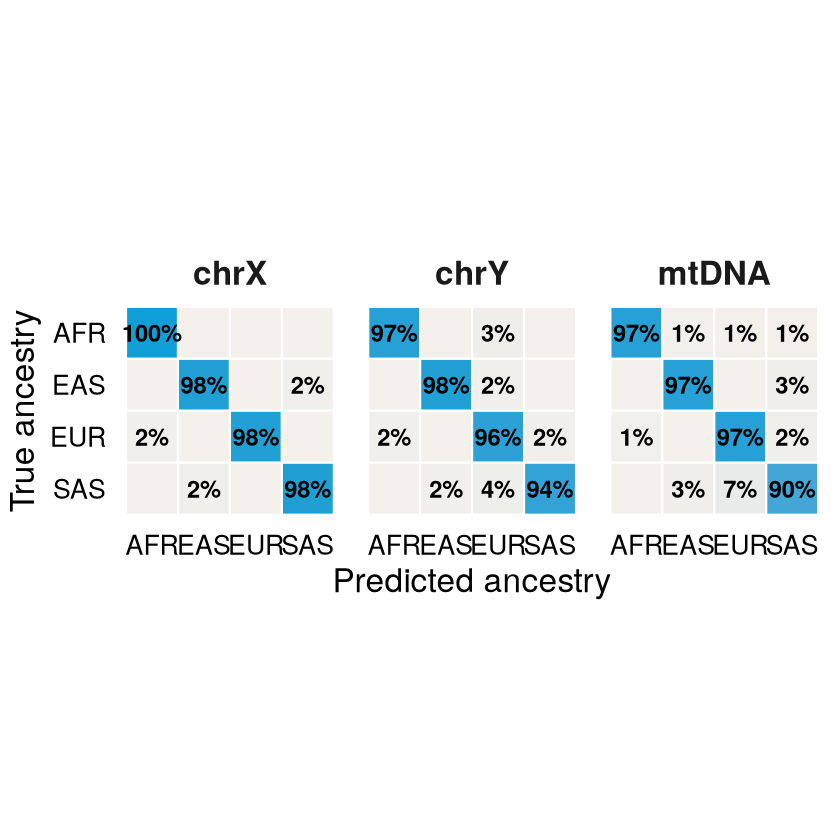

In [7]:
library(data.table)
library(ggplot2)

# ============================================================
# Matrice de confusion XGBoost par chromosome
#   x = predicted, y = true, fill = proportion
# ============================================================

files <- c(
   chrX  = "/srv/home/mlef0011/Phasomix/output/parental_origin/training/POP_no_AMR/chrX/xgboost_prediction.txt",
   chrY  = "/srv/home/mlef0011/Phasomix/output/parental_origin/training/POP_no_AMR/chrY/xgboost_prediction.txt",
   mtDNA = "/srv/home/mlef0011/Phasomix/output/parental_origin/training/POP_no_AMR/chrMT/xgboost_prediction.txt"
)

anc_levels <- c("AFR", "EAS", "EUR", "SAS")

# ---- 1. lecture + matrice de confusion (normalisee par ligne / true) ----
dt <- rbindlist(lapply(names(files), function(chr) {
   d <- fread(files[chr])
   d <- d[, .(n = .N), by = .(true_label, predicted_label)]
   d[, prop := n / sum(n), by = true_label]
   d[, chr := chr][]
}))

# completer les cellules vides avec 0 (pour que la grille soit complete)
grid <- CJ(true_label = anc_levels,
           predicted_label = anc_levels,
           chr = names(files))
dt <- merge(grid, dt, by = c("chr", "true_label", "predicted_label"),
            all.x = TRUE)
dt[is.na(prop), `:=`(n = 0, prop = 0)]

dt[, chr             := factor(chr, levels = names(files))]
dt[, true_label      := factor(true_label, levels = rev(anc_levels))]   # rev pour avoir AFR en haut
dt[, predicted_label := factor(predicted_label, levels = anc_levels)]

# ---- 2. plot ----
p <- ggplot(dt, aes(x = predicted_label, y = true_label, fill = prop)) +
   geom_tile(colour = "white", linewidth = 0.6) +
   geom_text(aes(label = ifelse(prop > 0,
                                 sprintf("%.0f%%", prop * 100),
                                 "")),
             colour = "black", size = 5, fontface = "bold") +
   facet_wrap(~ chr, nrow = 1) +
   scale_fill_gradient(low = "#F4F1EC", high = "#0F9ED5",
                       limits = c(0, 1),
                       labels = scales::percent_format(accuracy = 1)) +
   coord_equal() +
   labs(x = "Predicted ancestry", y = "True ancestry") +
   theme_minimal(base_size = 20) +
   theme(
      panel.grid       = element_blank(),
      strip.background = element_blank(),
      strip.text       = element_text(face = "bold", size =20),
      axis.text        = element_text(colour = "black"),
      axis.ticks       = element_blank(),
      axis.title       = element_text(colour = "black"),
      legend.position  = "nono",
      panel.spacing.x  = unit(1, "lines"),
      plot.margin      = margin(8, 10, 6, 6)
   )

p

svg("/srv/home/mlef0011/Phasomix/output/figures/xgboost_sex_chr_accuracy_no_AMR.svg",
               width = 9, height = 4)
print(p)
dev.off()

pdf 
  2

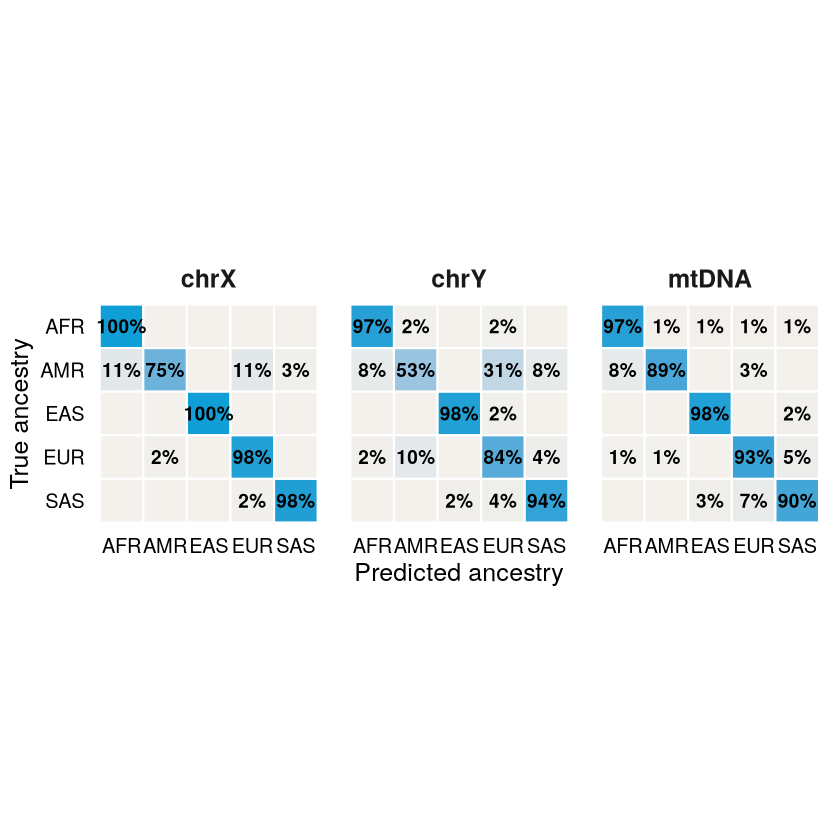

In [12]:
library(data.table)
library(ggplot2)

# ============================================================
# Matrice de confusion XGBoost par chromosome
#   x = predicted, y = true, fill = proportion
# ============================================================

files <- c(
   chrX  = "/srv/home/mlef0011/Phasomix/output/parental_origin/training/POP/chrX/xgboost_prediction.txt",
   chrY  = "/srv/home/mlef0011/Phasomix/output/parental_origin/training/POP/chrY/xgboost_prediction.txt",
   mtDNA = "/srv/home/mlef0011/Phasomix/output/parental_origin/training/POP/chrMT/xgboost_prediction.txt"
)

anc_levels <- c("AFR", "AMR", "EAS", "EUR", "SAS")

# ---- 1. lecture + matrice de confusion (normalisee par ligne / true) ----
dt <- rbindlist(lapply(names(files), function(chr) {
   d <- fread(files[chr])
   d <- d[, .(n = .N), by = .(true_label, predicted_label)]
   d[, prop := n / sum(n), by = true_label]
   d[, chr := chr][]
}))

# completer les cellules vides avec 0 (pour que la grille soit complete)
grid <- CJ(true_label = anc_levels,
           predicted_label = anc_levels,
           chr = names(files))
dt <- merge(grid, dt, by = c("chr", "true_label", "predicted_label"),
            all.x = TRUE)
dt[is.na(prop), `:=`(n = 0, prop = 0)]

dt[, chr             := factor(chr, levels = names(files))]
dt[, true_label      := factor(true_label, levels = rev(anc_levels))]   # rev pour avoir AFR en haut
dt[, predicted_label := factor(predicted_label, levels = anc_levels)]

# ---- 2. plot ----
p <- ggplot(dt, aes(x = predicted_label, y = true_label, fill = prop)) +
   geom_tile(colour = "white", linewidth = 0.6) +
   geom_text(aes(label = ifelse(prop > 0,
                                 sprintf("%.0f%%", prop * 100),
                                 "")),
             colour = "black", size = 4, fontface = "bold") +
   facet_wrap(~ chr, nrow = 1) +
   scale_fill_gradient(low = "#F4F1EC", high = "#0F9ED5",
                       limits = c(0, 1),
                       labels = scales::percent_format(accuracy = 1)) +
   coord_equal() +
   labs(x = "Predicted ancestry", y = "True ancestry") +
   theme_minimal(base_size = 15) +
   theme(
      panel.grid       = element_blank(),
      strip.background = element_blank(),
      strip.text       = element_text(face = "bold", size =15),
      axis.text        = element_text(colour = "black"),
      axis.ticks       = element_blank(),
      axis.title       = element_text(colour = "black"),
      legend.position  = "nono",
      panel.spacing.x  = unit(1, "lines"),
      plot.margin      = margin(8, 10, 6, 6)
   )

p


svg("/srv/home/mlef0011/Phasomix/output/figures/xgboost_sex_chr_accuracy.svg",
               width = 9, height = 4)
print(p)
dev.off()